In [125]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

### Iš anksto paruošiam įvairius embedding'us

In [126]:
distance_matrix = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels = np.load('ship-types.npy')
_, labels_encoded = np.unique(labels, return_inverse=True)

# Projekcijų sudarymas ir įvertinimas

In [127]:
embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=42
).fit_transform(distance_matrix)

embedding25 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=25,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

embedding100 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    n_components=100,
    max_iter=500,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

In [128]:
from zadu.measures import class_aware_trustworthiness_continuity

In [129]:
def measure_continuity_trustworthiness(
    original_flat: np.ndarray,
    embedding: np.ndarray,
    labels: np.ndarray[str]
) -> tuple[float]:
    
    trust_scores = []
    cont_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))

    return cont_score, trust_score

In [130]:
original_flat = original_data.reshape((-1, 250))
cont2, trust2 = measure_continuity_trustworthiness(
    original_flat, embedding, labels
)

cont25, trust25 = measure_continuity_trustworthiness(
    original_flat, embedding25, labels
)

cont100, trust100 = measure_continuity_trustworthiness(
    original_flat, embedding100, labels
)

In [131]:
import pandas as pd

data = {
    "Dimensija": [2, 25, 100],
    "Tęstinumas": [cont2, cont25, cont100],
    "Patikimumas": [trust2, trust25, trust100],
}

print(pd.DataFrame(data)\
    .to_latex()\
    .replace('.', ','))

\begin{tabular}{lrrr}
\toprule
 & Dimensija & Tęstinumas & Patikimumas \\
\midrule
0 & 2 & 0,988128 & 0,979466 \\
1 & 25 & 0,982141 & 0,965662 \\
2 & 100 & 0,979671 & 0,960213 \\
\bottomrule
\end{tabular}



> Kadangi tiek tęstinumo, tiek patikimumo viršija 0,95, tai yra labai gera projekcija lokalios struktūros atžvilgiu -> mes naudosime šitą dimensijos mažinimą toliau

# Hierarchinis klasterizavimas

In [132]:
n = original_data.shape[0]
np.sqrt(n / 2)
print(n)

750


#### Maksimum 21 klasterių tikrinsime 

In [133]:
all_metrics = {
    'Metrika': [],
    'Hiperparametrų rinkinys': [],
    'Dimensija': [],
    'Metodas': [],
    'Metrikos reikšmė': []
}

In [134]:
def calculate_wcbcr(clusters, distance_matrix):
    """ Calculate Within-Cluster to Between-Cluster Ratio (WCBCR). """

    clusters = np.array(clusters)
    distance_matrix = np.array(distance_matrix)
    unique_clusters = np.unique(clusters)

    # Group point indices by cluster label
    # Key - cluster number, value - list of indices that belong to that cluster number 
    cluster_members = {k: np.where(clusters == k)[0] for k in unique_clusters}

    # Compute medoid for each cluster
    centroids = {}
    for k, members in cluster_members.items():
        if len(members) == 1:
            centroids[k] = members[0]
        else:
            intra_distances = [sum(distance_matrix[p][q] for q in members) for p in members]
            centroids[k] = members[np.argmin(intra_distances)]

    # Numerator: sum of distances from each point to its cluster medoid
    numerator = sum(
        distance_matrix[point][centroids[k]]
        for k, members in cluster_members.items()
        for point in members
    )

    # Denominator: sum of distances between all distinct centroid pairs (i ≠ j)
    centroid_list = list(centroids.values())
    K = len(centroid_list)
    denominator = sum(
        distance_matrix[centroid_list[i]][centroid_list[j]]
        for i in range(K)
        for j in range(K)
        if i != j
    )

    if denominator == 0:
        raise ValueError("Denominator is zero: all centroids are identical.")

    return numerator / denominator

def inertia_score(embeddings, clusters):
    clusters = np.array(clusters)
    unique_clusters = np.unique(clusters)
    inertia = 0.0

    for cluster_id in unique_clusters:
        # Get all points belonging to this cluster
        mask = clusters == cluster_id
        cluster_points = embeddings[mask]
        
        # Calculate centroid
        centroid = cluster_points.mean(axis=0)
        
        # Sum of squared euclidean distances from each point to its centroid
        diff = cluster_points - centroid
        inertia += np.sum(diff ** 2)
    
    return inertia

In [135]:
def evaluate_clustering_dist_mat(dist_mat, data_flat, max_n, labels, linkage):
    """
    Grazina: 
        Siluetu,
        WCBRC,
        ARI,
        NMI,
        Calinski-Harabasz,
        Davies-Bouldvin
    """

    silhouette_scores = []
    inertia_scores = []
    ari_scores = []
    nmi_scores = []
    ch_scores = []
    db_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage=linkage)\
            .fit_predict(dist_mat)

        score = silhouette_score(dist_mat, clusters, metric='precomputed')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        wcbcr = calculate_wcbcr(clusters, dist_mat)
        inertia_scores.append(wcbcr)

        ari_scores.append( adjusted_rand_score(labels, clusters) )
        nmi_scores.append( normalized_mutual_info_score(labels, clusters) )

        ch_scores.append( calinski_harabasz_score(data_flat, clusters) )
        db_scores.append( davies_bouldin_score(data_flat, clusters) )

    return silhouette_scores, inertia_scores, ari_scores, nmi_scores, ch_scores, db_scores

def evaluate_clustering_embeddings(embedding, max_n, labels, linkage):
    """
    Grazina: 
        Siluetu,
        WCBRC,
        ARI,
        NMI,
        Calinski-Harabasz,
        Davies-Bouldvin
    """

    silhouette_scores = []
    inertia_scores = []
    ari_scores = []
    nmi_scores = []
    ch_scores = []
    db_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage=linkage)\
            .fit_predict(embedding)

        score = silhouette_score(embedding, clusters, metric='euclidean')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        inertia = inertia_score(embedding, clusters)
        inertia_scores.append(inertia)

        ari_scores.append( adjusted_rand_score(labels, clusters) )
        nmi_scores.append( normalized_mutual_info_score(labels, clusters) )

        ch_scores.append( calinski_harabasz_score(embedding, clusters) )
        db_scores.append( davies_bouldin_score(embedding, clusters) )

    return silhouette_scores, inertia_scores, ari_scores, nmi_scores, ch_scores, db_scores

In [136]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [137]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

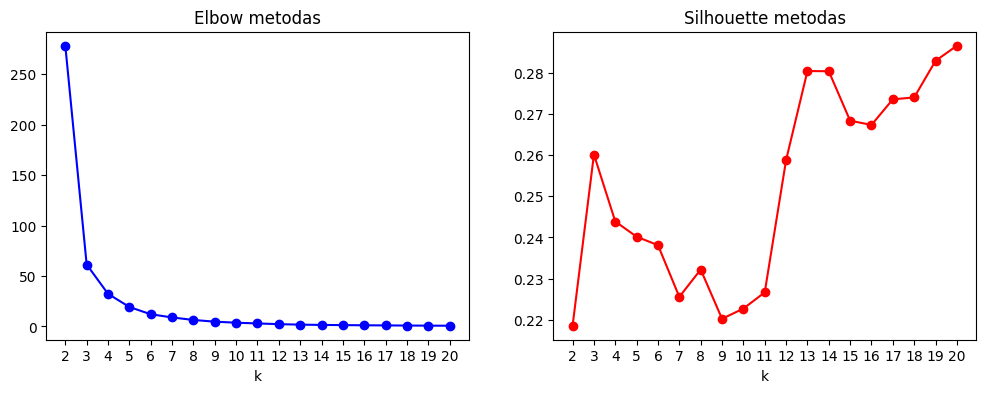

In [138]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_dist_mat(
    distance_matrix,
    original_flat,
    21,
    labels,
    linkage='complete'
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 21), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 21), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.show()

In [139]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_dist_mat(
        distance_matrix,
        original_flat,
        21,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['originali'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

### Pagal siluetus: 21, pagal elbow - 5

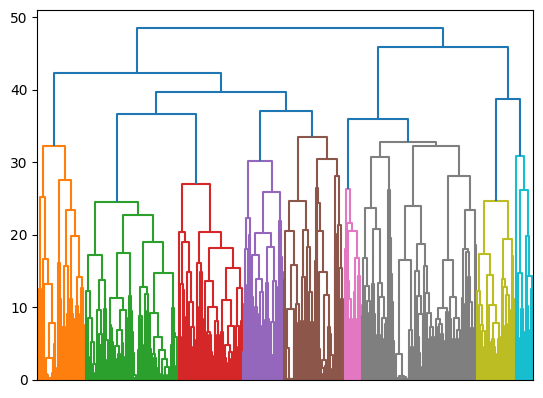

In [140]:
model = AgglomerativeClustering(
    21, metric='precomputed',
    linkage='complete',
    compute_distances=True 
)

clusters21 = model.fit_predict(distance_matrix)

plot_dendrogram(model, truncate_mode="level")
plt.xticks(ticks=[], labels=[])
plt.show()

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

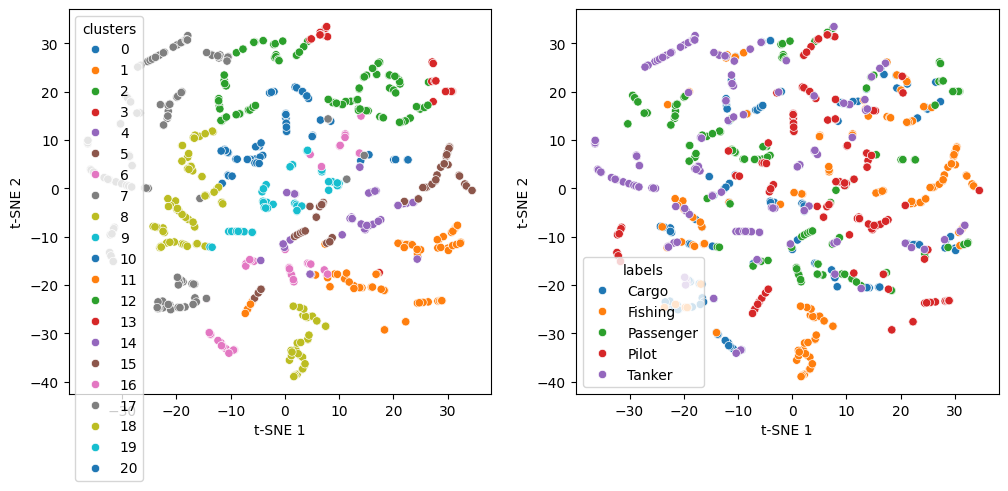

In [141]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters21

n_clusters = len(np.unique(clusters21))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 2

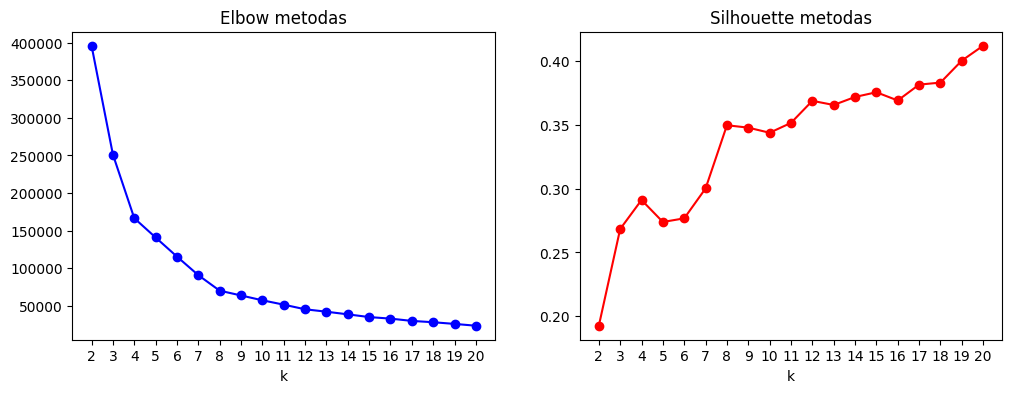

In [142]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding, max_n=21, labels=labels, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 21), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 21), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.show()

In [143]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding,
        21,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['2'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

### Pagal elbow metodą - 10, pagal siluetus - 21

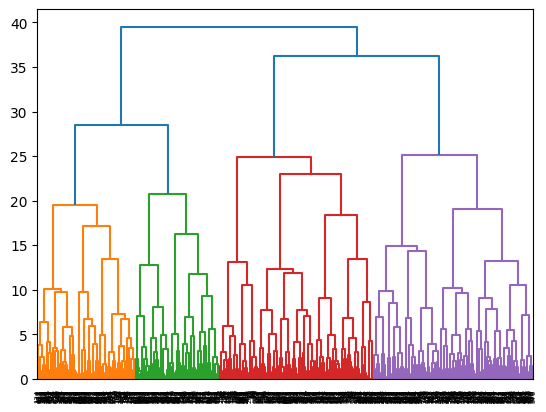

In [144]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='average',
    compute_distances=True 
)

clusters = model.fit_predict(embedding)

plot_dendrogram(model, truncate_mode="level")

In [145]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding, max_n=21, labels=labels, linkage='complete')

In [146]:
clusters5 = AgglomerativeClustering(
    10, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding)

clusters21 = AgglomerativeClustering(
    21, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

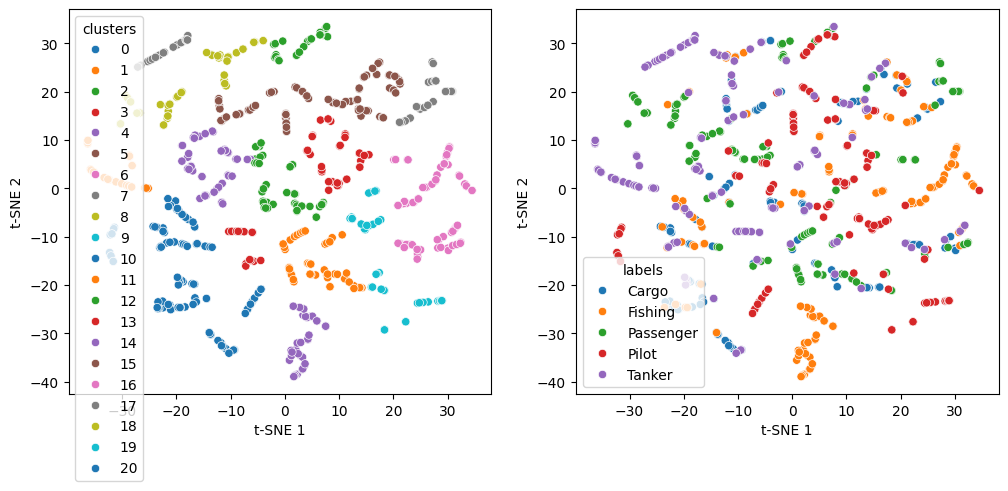

In [147]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters21

n_clusters = len(np.unique(clusters21))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

n_clusters = len(np.unique(clusters5))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 25

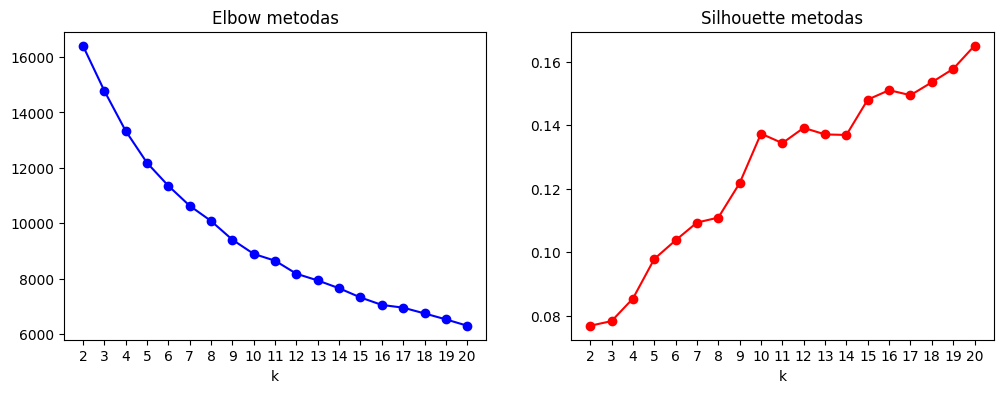

In [148]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding25, labels=labels, max_n=21, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 21), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 21), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.show()

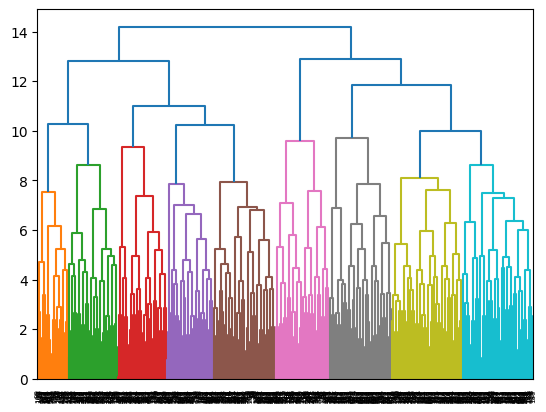

In [149]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='complete',
    compute_distances=True 
)

clusters = model.fit_predict(embedding25)

plot_dendrogram(model, truncate_mode="level")

In [150]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding25,
        21,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['25'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

In [151]:
clusters21 = AgglomerativeClustering(
    21, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding25)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

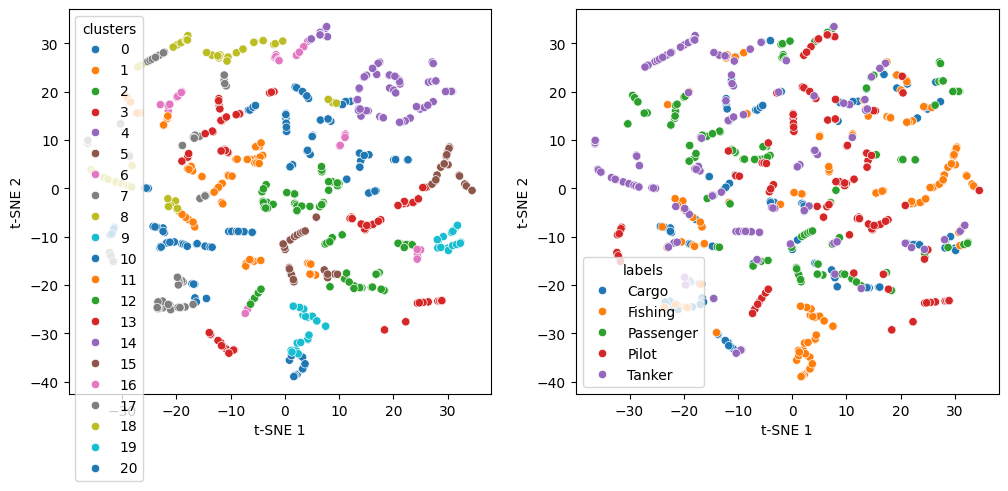

In [152]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters21

n_clusters = len(np.unique(clusters21))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
    ax=axs[0]
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
)

### Dimensija 100

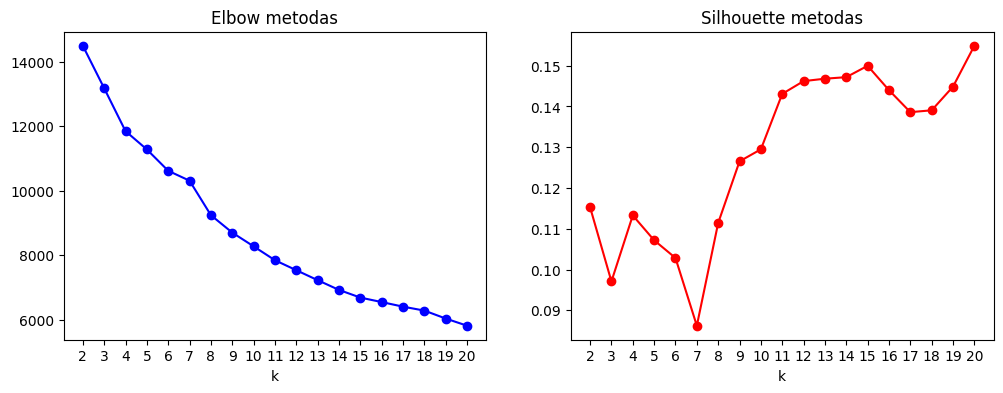

In [153]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding100, max_n=21, labels=labels, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 21), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 21), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,21), labels=[str(x) for x in range(2, 21)])

plt.show()

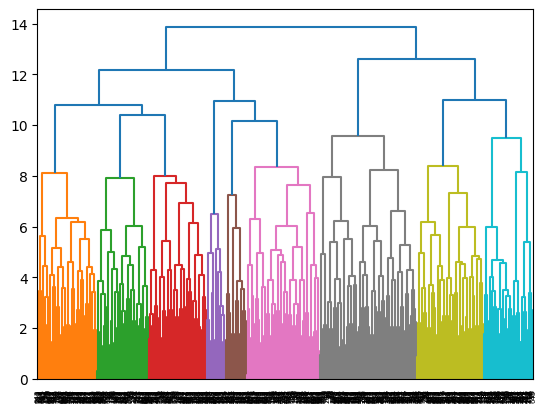

In [154]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='complete',
    compute_distances=True 
)

clusters = model.fit_predict(embedding100)

plot_dendrogram(model, truncate_mode="level")

In [155]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding100,
        21,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['100'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

In [156]:
clusters21 = AgglomerativeClustering(
    21, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding100)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

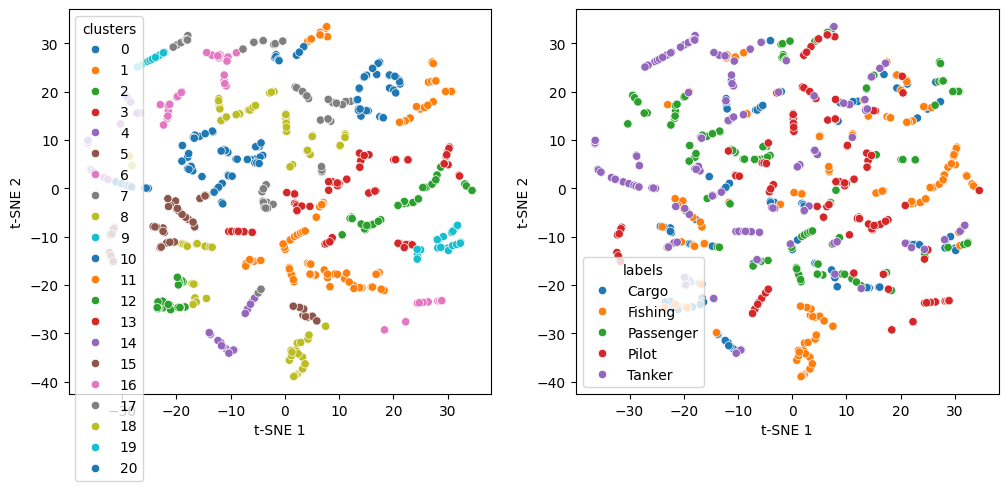

In [157]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters21

n_clusters = len(np.unique(clusters21))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
    ax=axs[0]
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
)

In [158]:
result_df = pd.DataFrame(all_metrics)

In [159]:
for metrika, metric_results in result_df.groupby('Metrika'):
    if metrika not in ['ARI', 'NMI']:
        continue

    index_best_metric = metric_results['Metrikos reikšmė'].argmax()
    best_hyper = metric_results.iloc[index_best_metric, :]

    print( f'Metrikai {metrika} geriausia dimensija:\n', best_hyper['Dimensija'] )
    print( f'Metrikai {metrika} geriausias jungties matas:\n', best_hyper['Hiperparametrų rinkinys'] )
    print('\n')

Metrikai ARI geriausia dimensija:
 2
Metrikai ARI geriausias jungties matas:
 {'Jungimo matas': 'complete'}


Metrikai NMI geriausia dimensija:
 2
Metrikai NMI geriausias jungties matas:
 {'Jungimo matas': 'single'}




# Kmeans


In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score, 
                             normalized_mutual_info_score, jaccard_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [161]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score, jaccard_score
from sklearn.manifold import TSNE
from matplotlib.ticker import FixedLocator

def find_elbow_k(k_range, sse):
    """Automatiškai randa alkūnės tašką (didžiausią kreivės lūžį)."""
    p1 = np.array([k_range[0], sse[0]])
    p2 = np.array([k_range[-1], sse[-1]])
    distances = []
    for i in range(len(k_range)):
        p0 = np.array([k_range[i], sse[i]])
        dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    return k_range[np.argmax(distances)]

def draw_styled_clusters(ax, data, labels, title, is_tsne=False):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Pridedame ašis projekcijai
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    for i, label in enumerate(unique_labels):
        points = data[labels == label]
        color = colors[i]
        ax.scatter(points[:, 0], points[:, 1], color=color, s=15, alpha=0.5)

        if len(data) < 300:
            indices = np.where(labels == label)[0]
            for idx, pt in zip(indices, points):
                ax.text(pt[0], pt[1], str(idx), fontsize=7, color=color)

        if len(points) > 2:
            mean = np.mean(points, axis=0)
            try:
                cov = np.cov(points, rowvar=False)
                vals, vecs = np.linalg.eigh(cov)
                order = vals.argsort()[::-1]
                vals, vecs = vals[order], vecs[:, order]
                theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
                width, height = 2 * 2 * np.sqrt(np.abs(vals))

                ell = patches.Ellipse(
                    xy=mean,
                    width=width,
                    height=height,
                    angle=theta,
                    edgecolor=color,
                    facecolor='none',
                    linewidth=1.5,
                    hatch='////',
                    alpha=0.2
                )
                ax.add_patch(ell)
                ax.text(mean[0], mean[1], f"K{label}", fontsize=12, fontweight='bold', color='black', 
                        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
            except:
                pass # Jei kovariacija neskaičiuojama (pvz. kolinearūs taškai)

def perform_full_analysis(data, labels_true, labels_true_str, dim_name, viz_2d=None):
    print(f"\n{'-'*15} ANALIZĖ: {dim_name} {'-'*15}")

    k_range = range(2, 21)
    sse = []
    sil_scores = []
    results_by_k = {}

    # Klasterizacija vykdoma 'data' erdvėje (gali būti 2D, 25D, 50D ir t.t.)
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        l_pred = km.fit_predict(data)
        sse.append(km.inertia_)
        sil_scores.append(silhouette_score(data, l_pred))
        
        results_by_k[k] = {
            "sil": sil_scores[-1],
            "ch": calinski_harabasz_score(data, l_pred),
            "db": davies_bouldin_score(data, l_pred),
            "ari": adjusted_rand_score(labels_true, l_pred),
            "nmi": normalized_mutual_info_score(labels_true, l_pred),
            "jac": jaccard_score(labels_true, l_pred, average="macro"),
        }

    k_silhouette = k_range[np.argmax(sil_scores)]
    k_elbow = find_elbow_k(list(k_range), sse)

    # Nustatome vizualizacijos koordinates
    # Jei viz_2d neperduotas, skaičiuojame jį iš 'data'
    if viz_2d is None:
        if data.shape[1] == 2:
            viz_2d = data
        else:
            print(f"Generuojama t-SNE projekcija vizualizacijai ({dim_name})...")
            viz_2d = TSNE(n_components=2, random_state=42).fit_transform(data)

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Elbow
    ax1.plot(k_range, sse, "bo-", markersize=4)
    ax1.set_title("Alkūnės metodas")
    ax1.set_xlabel("Klasterių skaičius")
    ax1.set_ylabel("Inercija (WCBRC)")
    # ax1.axvline(k_elbow, color="orange", ls="--", label=f"Alkūnė k={k_elbow}")
    ax1.xaxis.set_major_locator(FixedLocator(list(k_range)))
    # ax1.grid(False, alpha=0.3)

    # 2. Silhouette
    ax2.plot(k_range, sil_scores, "ro-", markersize=4)
    ax2.set_title("Silhouette koeficientas")
    ax2.set_xlabel("Klasterių skaičius (k)")
    ax2.set_ylabel("Vidutinis Siluetas")
    # ax2.axvline(k_silhouette, color="green", ls="--", label=f"Optimumas k={k_silhouette}")
    ax2.xaxis.set_major_locator(FixedLocator(list(k_range)))
    # ax2.grid(False, alpha=0.3)

    # 3. K-Means (naudojant perduotą viz_2d)
    final_labels_opt = KMeans(n_clusters=k_silhouette, random_state=42, n_init=10).fit_predict(data)
    draw_styled_clusters(ax3, viz_2d, final_labels_opt, f"K-Means (k={k_silhouette})", is_tsne=True)

    # 4. Tikrosios klasės (naudojant perduotą viz_2d)
    unique_types = sorted(np.unique(labels_true_str)) 
    tab10_colors = plt.cm.tab10.colors 
    
    ax4.set_title(f"Tikrosios klasės ({dim_name})", fontsize=12, fontweight='bold')
    for i, ship_type in enumerate(unique_types):
        mask = (labels_true_str == ship_type)
        ax4.scatter(viz_2d[mask, 0], viz_2d[mask, 1], label=ship_type, s=30, alpha=0.7, 
                    color=tab10_colors[i % 10], edgecolors='white', linewidth=0.5)
    
    ax4.set_xlabel("t-SNE 1")
    ax4.set_ylabel("t-SNE 2")
    ax4.legend(title="labels", loc='upper left', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.show()

    res_opt = results_by_k[k_silhouette]
    return [{"Dimensija": f"{dim_name} (Opt)", "K": k_silhouette, "Metodas": "Silhouette", **res_opt}]



In [162]:
# --- 3. PAGRINDINĖ ANALIZĖ ---
dist_mat = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels_true_str = np.load('ship-types.npy')
le = LabelEncoder()
labels_true = le.fit_transform(labels_true_str)

# Empyrinis K
n_samples = dist_mat.shape[0]
empiric_k = int(np.sqrt(n_samples / 2))

# Paleidimas
final_summary = []

num_classes = len(np.unique(labels_true_str))

print(f"Originalių klasių (laivų tipų) skaičius: {num_classes}")

Originalių klasių (laivų tipų) skaičius: 5



--------------- ANALIZĖ: Originali ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_2115/3023460574.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


Generuojama t-SNE projekcija vizualizacijai (Originali)...


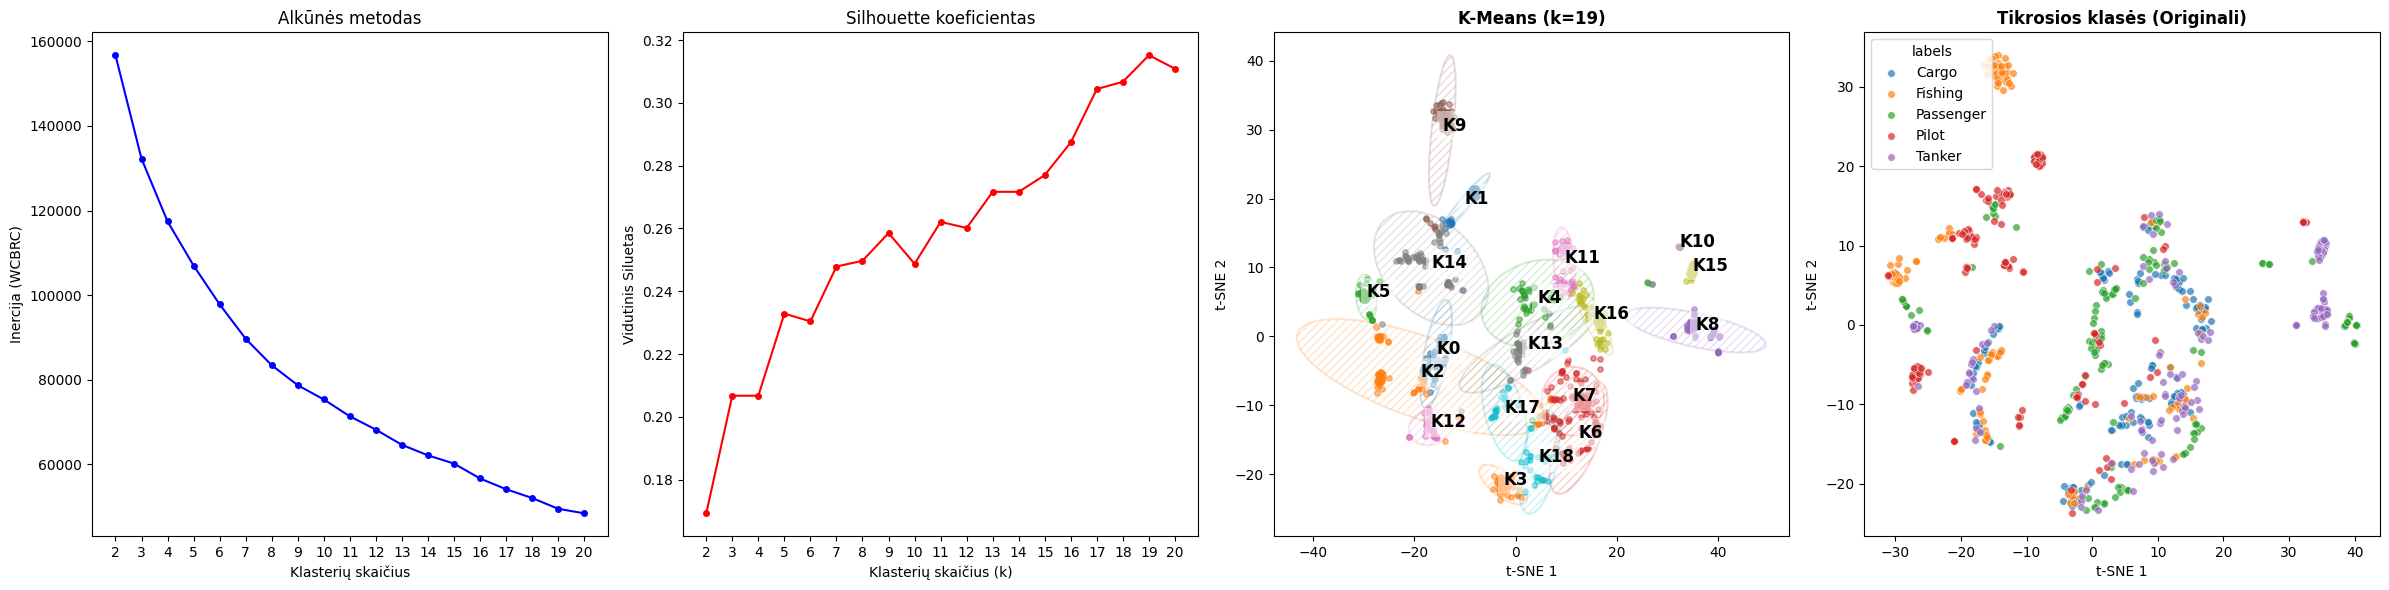

In [163]:
original_data_scaled = StandardScaler().fit_transform(original_data.reshape(n_samples, -1))

final_summary.append(perform_full_analysis(original_data_scaled, labels_true, labels_true_str, "Originali"))


--------------- ANALIZĖ: 2D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_2115/3023460574.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


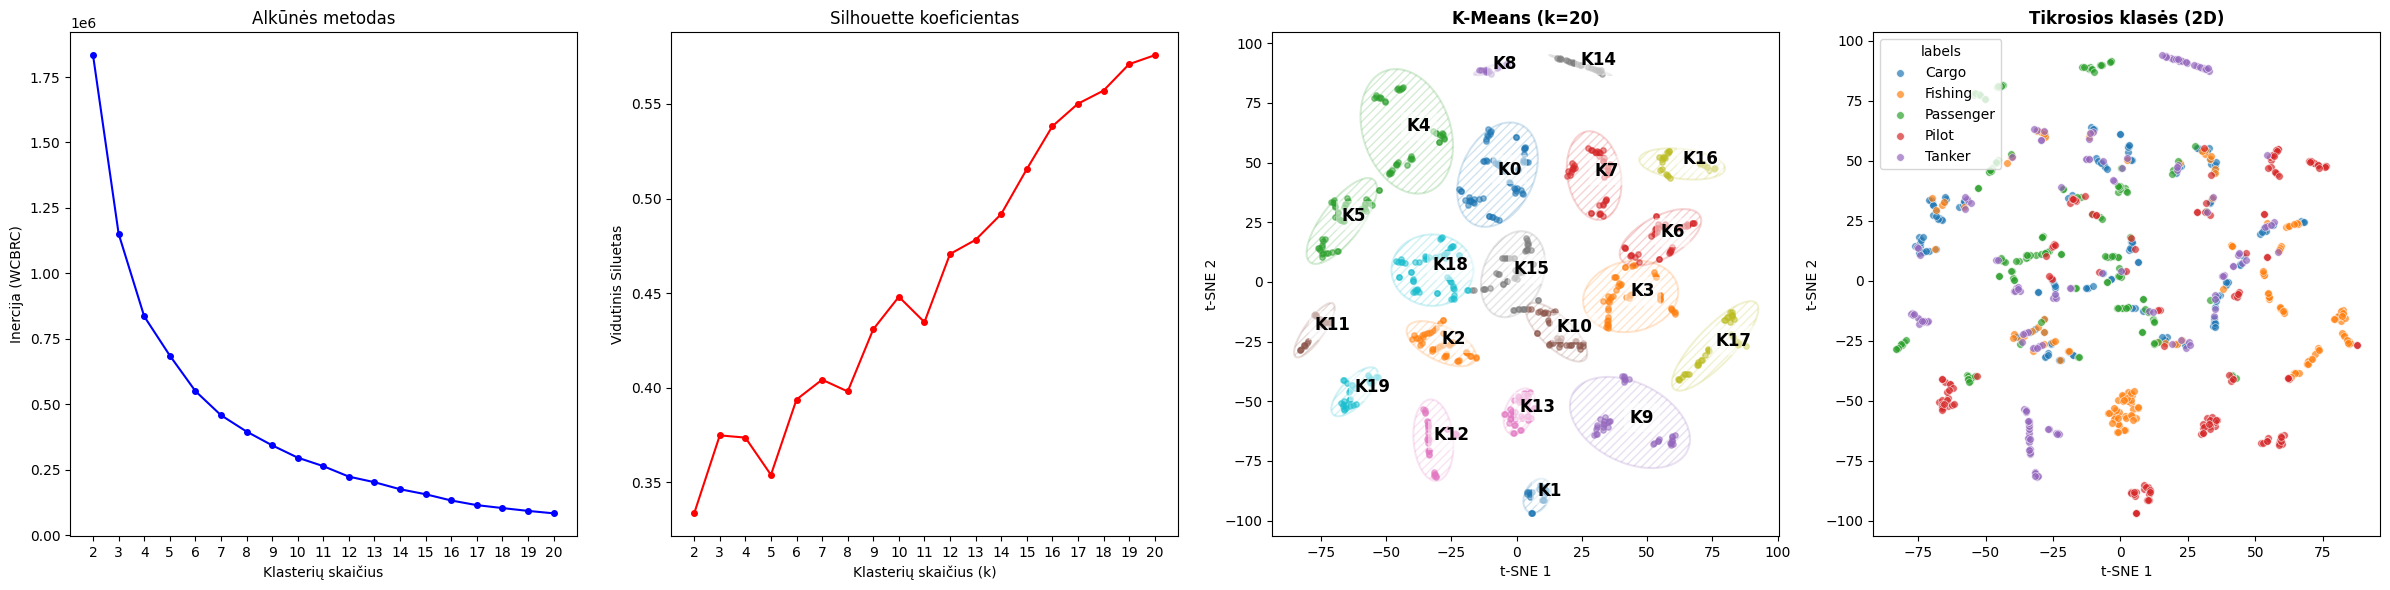


--------------- ANALIZĖ: 25D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_2115/3023460574.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


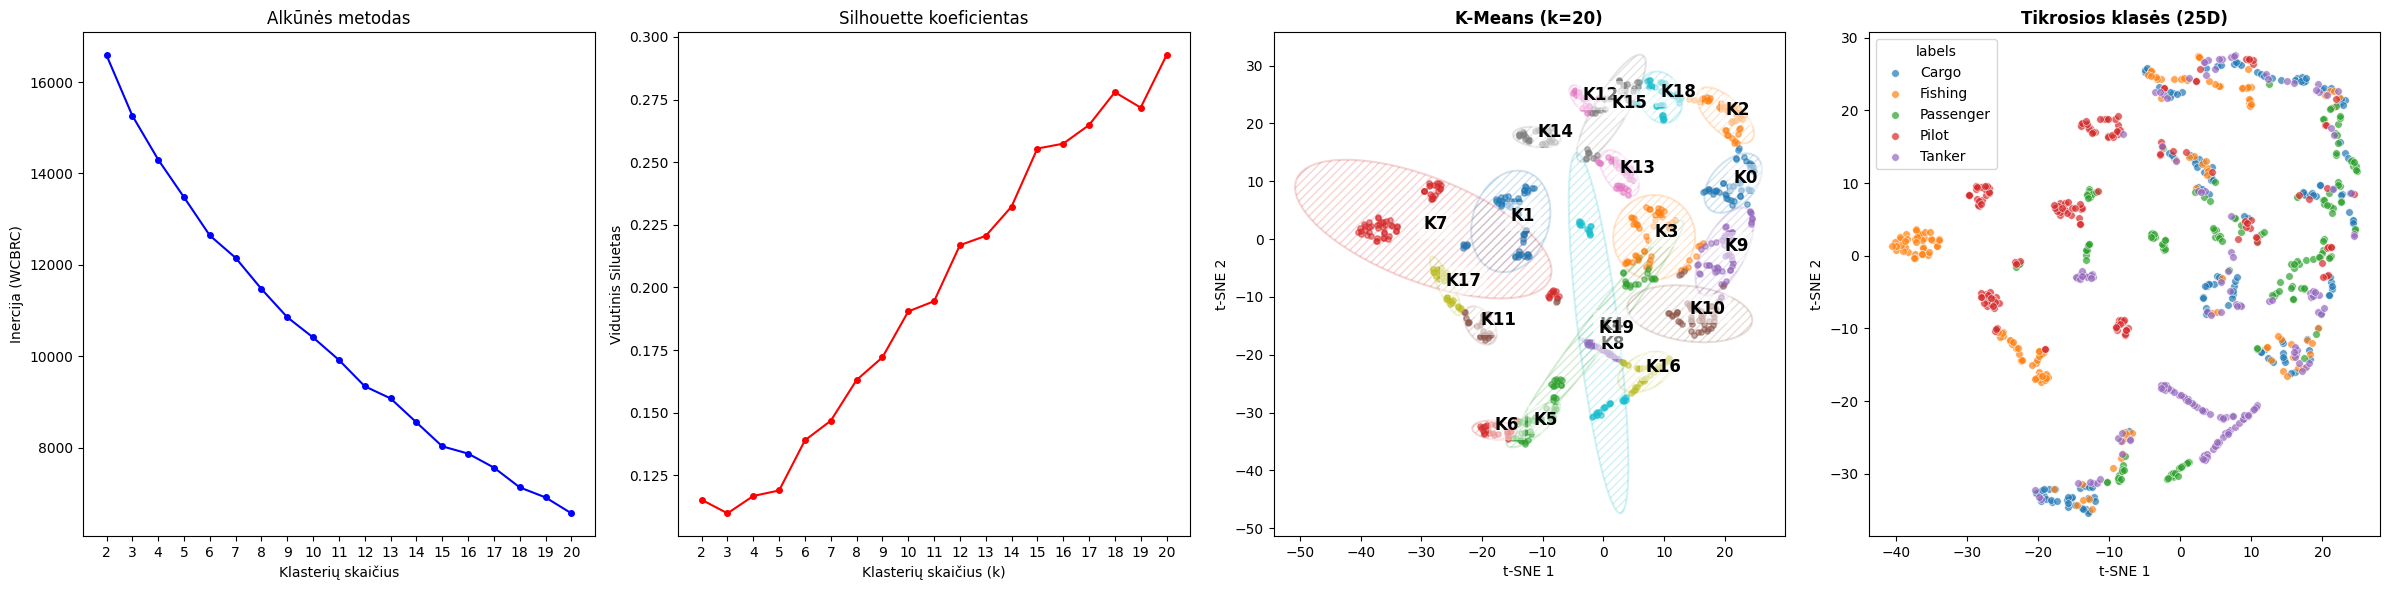


--------------- ANALIZĖ: 50D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_2115/3023460574.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


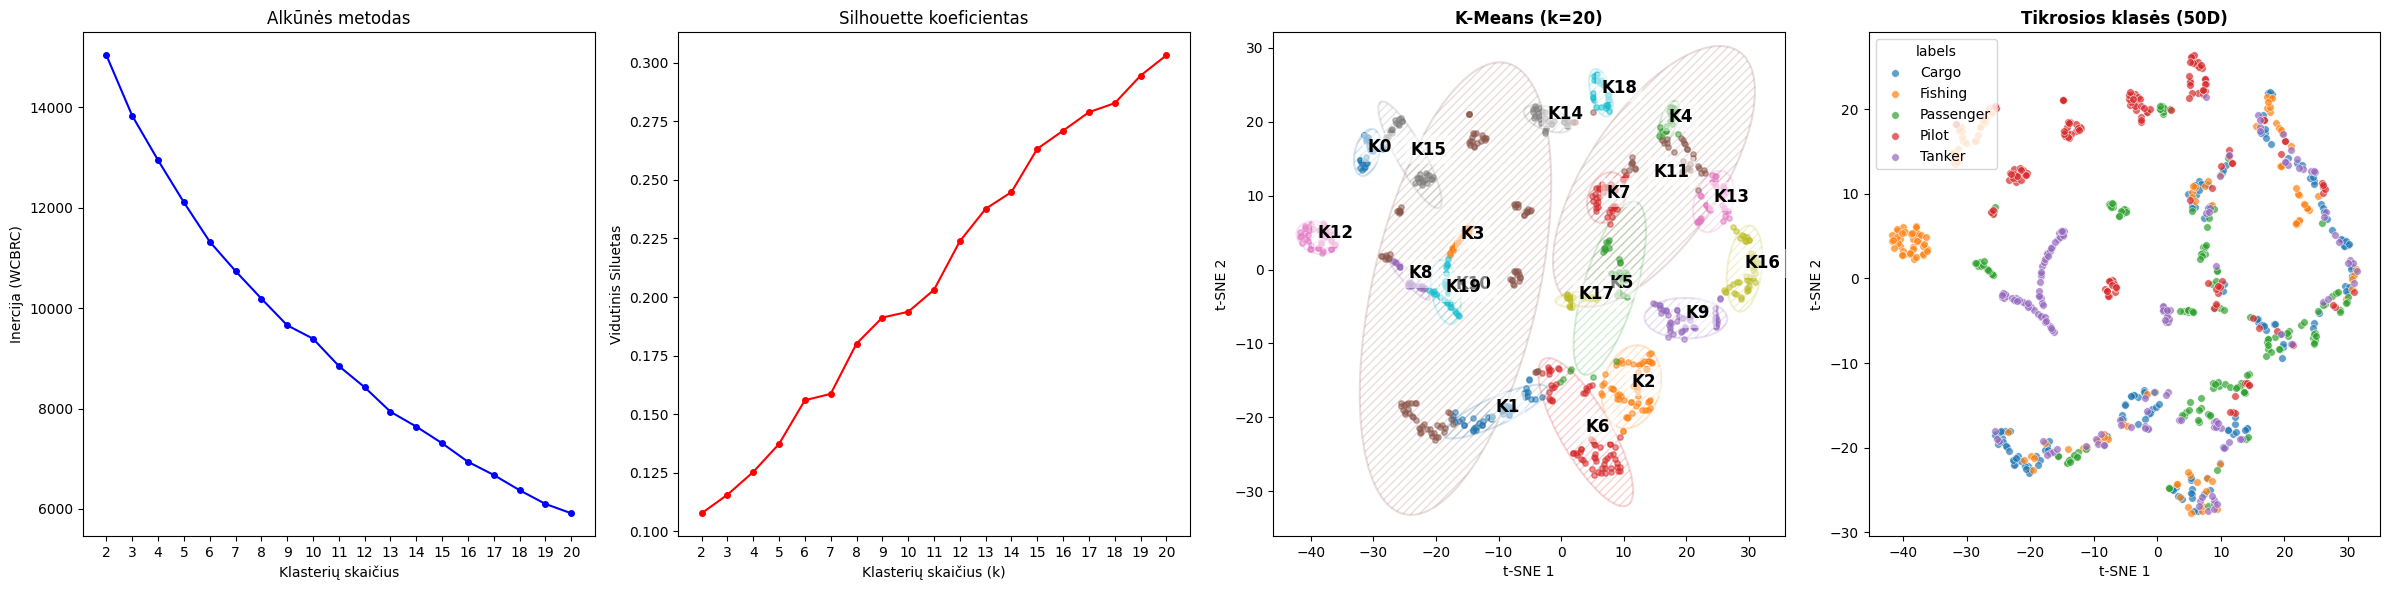


--------------- ANALIZĖ: 100D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_2115/3023460574.py:16: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p0)) / np.linalg.norm(p2 - p1)


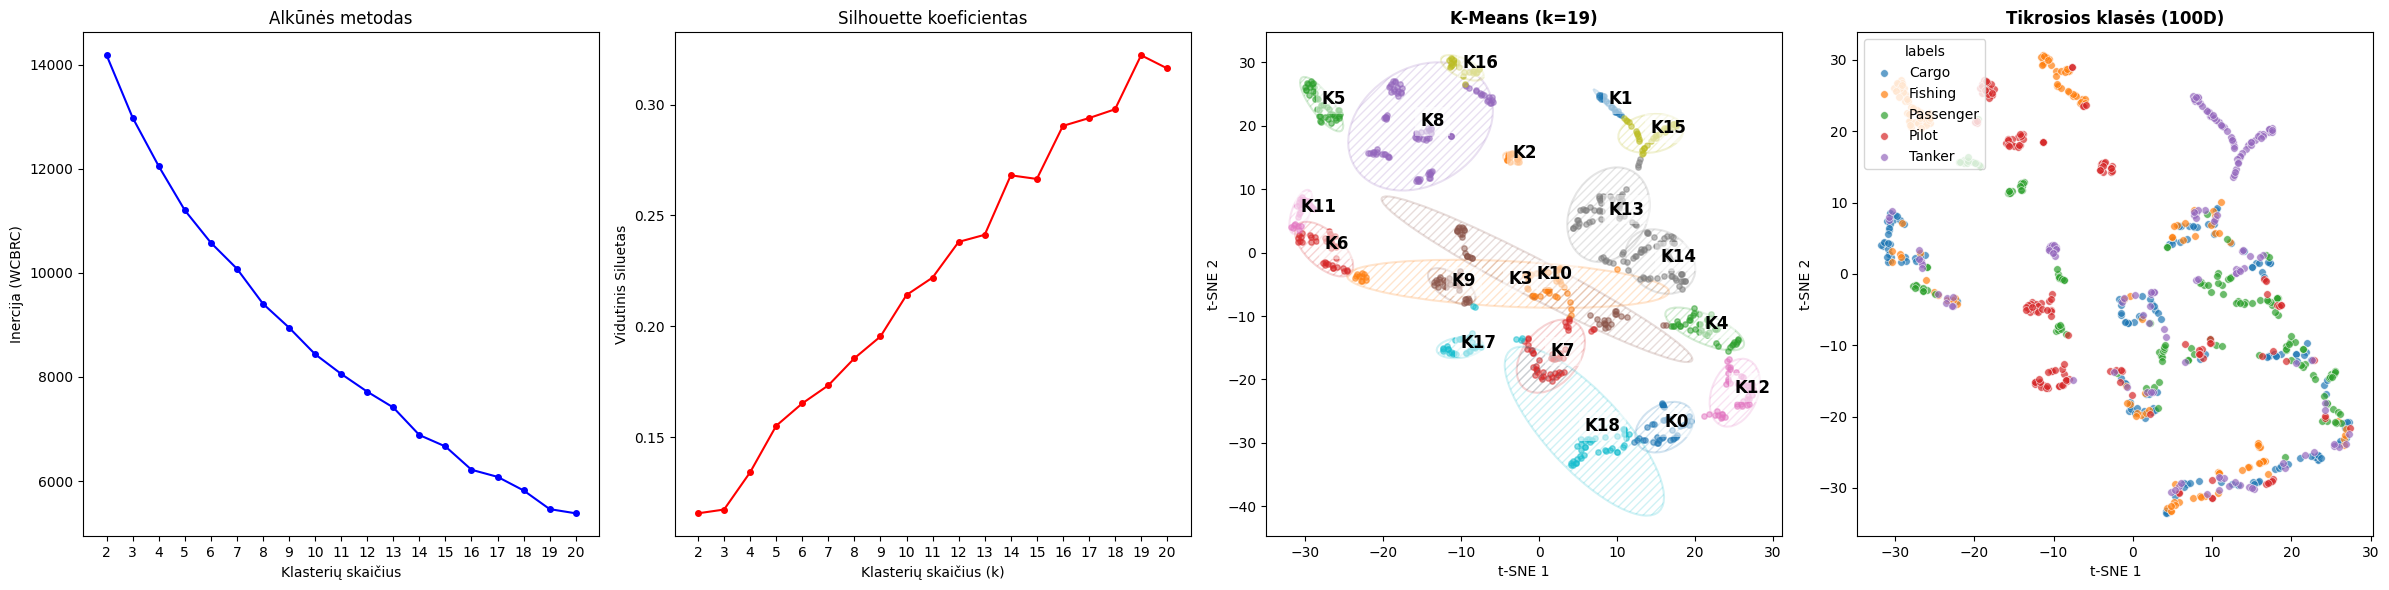

In [164]:

for d in [2, 25, 50, 100]:
    # Sukuriame d-dimensinį embeddingą (tai bus duomenys klasterizacijai)
    emb_d = TSNE(n_components=d, perplexity=5, metric='precomputed', method='exact', init="random", random_state=42).fit_transform(dist_mat)
    
    # Jei d > 2, vizualizacijai sukuriamas 2D vaizdas būtent iš TO embeddingo
    # Tai parodys, kaip 25D struktūra atrodo suspausta į 2D
    if d == 2:
        v2d = emb_d
    else:
        v2d = TSNE(n_components=2, random_state=42).fit_transform(emb_d)
    
    # Kviečiame analizę perduodami abu: emb_d (skaičiavimams) ir v2d (piešimui)
    final_summary.append(perform_full_analysis(emb_d, labels_true, labels_true_str, f"{d}D", viz_2d=v2d))

In [165]:

# --- 4. GALUTINIS PALYGINIMAS ---
df_final = pd.DataFrame(final_summary)
print("\n" + "="*100)
print("VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS")
print("="*100)
print(df_final.to_string(index=False))


VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS
                                                                                                                                                                                                                                    0
{'Dimensija': 'Originali (Opt)', 'K': 19, 'Metodas': 'Silhouette', 'sil': 0.3151729471281904, 'ch': 113.16356399489432, 'db': 1.224901664756759, 'ari': 0.11209968422794811, 'nmi': 0.27714661616070274, 'jac': 0.006672923471062306}
       {'Dimensija': '2D (Opt)', 'K': 20, 'Metodas': 'Silhouette', 'sil': 0.5757472515106201, 'ch': 1292.412841796875, 'db': 0.5524589701664594, 'ari': 0.12385385819421348, 'nmi': 0.32403906082694967, 'jac': 0.009697682629861199}
     {'Dimensija': '25D (Opt)', 'K': 20, 'Metodas': 'Silhouette', 'sil': 0.29270556569099426, 'ch': 69.35386657714844, 'db': 1.3452387262277996, 'ari': 0.09880925927950399, 'nmi': 0.27082710215244393, 'jac': 0.013879731379731381}
       {'Dimensija': '50D (Opt)', 'K'

In [174]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np
import itertools

def evaluate_stability(data, k=20, n_iter=10, sample_pct=0.8):
    n_samples = data.shape[0]
    all_results = []

    # 1. Paleidimai su skirtingais random_state
    for i in range(n_iter):
        indices = np.random.choice(range(n_samples), size=int(n_samples * sample_pct), replace=False)
        subset = data[indices]

        km = KMeans(n_clusters=k, n_init=10, random_state=i)
        labels = km.fit_predict(subset)

        all_results.append((set(indices), dict(zip(indices, labels))))

    # 2. Lyginam run vs run
    ari_scores = []
    nmi_scores = []

    pairs = list(itertools.combinations(range(n_iter), 2))

    for i, j in pairs:
        idx1, lab1 = all_results[i]
        idx2, lab2 = all_results[j]

        common = list(idx1.intersection(idx2))
        if len(common) > 0:
            y1 = [lab1[idx] for idx in common]
            y2 = [lab2[idx] for idx in common]

            ari_scores.append(adjusted_rand_score(y1, y2))
            nmi_scores.append(normalized_mutual_info_score(y1, y2))

    print("\nSTABILUMAS (run vs run):")
    print(f"ARI: {np.mean(ari_scores):.4f} ± {np.std(ari_scores):.4f}")
    print(f"NMI: {np.mean(nmi_scores):.4f} ± {np.std(nmi_scores):.4f}")

    return np.mean(ari_scores), np.mean(nmi_scores)

In [175]:
from sklearn.manifold import TSNE

emb_100d = TSNE(
    n_components=100,
    perplexity=5,
    metric='precomputed',
    method='exact',
    init="random",
    random_state=42
).fit_transform(dist_mat)

evaluate_stability(
    data=emb_100d,
    k=20,
    n_iter=10,
    sample_pct=0.8
)

/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)



STABILUMAS (run vs run):
ARI: 0.1168 ± 0.0192
NMI: 0.3932 ± 0.0267


(np.float64(0.1168406408936151), np.float64(0.3931927106740933))

In [177]:
import numpy as np
import itertools
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def match_labels_hungarian(labels1, labels2):
    # Sudarom „confusion matrix“
    cm = confusion_matrix(labels1, labels2)
    
    # Randam optimalų atitikimą (maximizuojam sutapimus)
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Sukuriam mapping
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    # Peržymim labels2
    new_labels2 = np.array([mapping[label] for label in labels2])
    
    return new_labels2

def matching_points_hungarian(data, k=20, n_iter=10):
    all_labels = []

    # 1. Paleidžiam KMeans kelis kartus
    for i in range(n_iter):
        km = KMeans(n_clusters=k, n_init=10, random_state=i)
        labels = km.fit_predict(data)
        all_labels.append(labels)

    matches = []
    pairs = list(itertools.combinations(range(n_iter), 2))

    # 2. Lyginam su label matching
    for i, j in pairs:
        l1 = all_labels[i]
        l2 = all_labels[j]

        l2_matched = match_labels_hungarian(l1, l2)

        same = np.sum(l1 == l2_matched)
        matches.append(same / len(l1))

    print("\nSUTAMPANČIŲ TAŠKŲ % (su label matching):")
    print(f"{np.mean(matches)*100:.2f}% ± {np.std(matches)*100:.2f}%")

    return np.mean(matches), np.std(matches)

matching_points_hungarian(
    data=emb_100d,
    k=20,
    n_iter=10
)


SUTAMPANČIŲ TAŠKŲ % (su label matching):
39.04% ± 4.50%


(np.float64(0.3904296296296296), np.float64(0.045023155755497785))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# --- LOAD DATA ---
dist_mat = np.load('dist_mat.npy')
labels_true_str = np.load('ship-types.npy')

le = LabelEncoder()
labels_true = le.fit_transform(labels_true_str)

# --- SETTINGS ---
n_runs = 10
d = 100
k = 20

results = []

for run_id in range(n_runs):
    seed = 42 + run_id

    print(f"Run {run_id+1}/{n_runs}...")

    # 1. 100D t-SNE embedding
    emb_100d = TSNE(
        n_components=d,
        perplexity=5,
        metric='precomputed',
        method='exact',
        init='random',
        m
        random_state=seed
    ).fit_transform(dist_mat)

    # 2. KMeans with fixed k=20
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=seed
    )
    labels_pred = km.fit_predict(emb_100d)

    # 3. Metrics against true labels
    ari = adjusted_rand_score(labels_true, labels_pred)
    nmi = normalized_mutual_info_score(labels_true, labels_pred)

    results.append({
        "run": run_id + 1,
        "ARI": ari,
        "NMI": nmi
    })

# --- ALL RUN RESULTS ---
results_df = pd.DataFrame(results)
print("\nAll runs:")
print(results_df)

# --- SUMMARY ---
ari_mean = results_df["ARI"].mean()
ari_sd = results_df["ARI"].std(ddof=1)

nmi_mean = results_df["NMI"].mean()
nmi_sd = results_df["NMI"].std(ddof=1)

print("\nStability test summary for 100D, k=20:")
print(f"ARI mean = {ari_mean:.4f}")
print(f"ARI SD   = {ari_sd:.4f}")
print(f"NMI mean = {nmi_mean:.4f}")
print(f"NMI SD   = {nmi_sd:.4f}")

summary_df = pd.DataFrame([{
    "Dimension": "100D",
    "K": 20,
    "Runs": n_runs,
    "ARI_mean": ari_mean,
    "ARI_SD": ari_sd,
    "NMI_mean": nmi_mean,
    "NMI_SD": nmi_sd
}])

print("\nSummary table:")
print(summary_df)

Run 1/10...
Run 2/10...
Run 3/10...
Run 4/10...
Run 5/10...


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)


Run 6/10...


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)


Run 7/10...


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)


Run 8/10...


/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:946: RuntimeWarning: overflow encountered in square
  distances **= 2
/Users/vilte/Desktop/6 sem/vizualizavimas/1 Lab/Laboratorinis/venv/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:61: RuntimeWarning: overflow encountered in cast
  distances = distances.astype(np.float32, copy=False)


Run 9/10...


ValueError: Input X contains infinity or a value too large for dtype('float64').

# DBSCAN

In [167]:
eps_values = np.linspace(0.0001, np.percentile(embedding, 95), 100)
min_samples_values = range(2, 14)

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        clusters = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed').fit_predict(distance_matrix)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        mask = clusters != -1

        if n_clusters < 2 or mask.sum() < 2:
            continue

        score = silhouette_score(distance_matrix[np.ix_(mask, mask)], clusters[mask], metric='precomputed')
        jaccard = jaccard_score(labels_encoded, clusters, average='weighted')
        results.append((eps, min_samples, n_clusters, score, jaccard, mask.mean()))


best_eps, best_min_samples, best_n_clusters, best_silhouette, best_jaccard, best_kept = max(
    results,
    key=lambda x: x[3]
)

print(f"Best eps: {best_eps:.5f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Clusters: {best_n_clusters}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"Jaccard Score: {best_jaccard:.4f}")
print(f"Non-noise ratio: {best_kept:.2%}")

Best eps: 0.29120
Best min_samples: 11
Clusters: 2
Silhouette Score: 0.9968
Jaccard Score: 0.0000
Non-noise ratio: 3.73%


In [168]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters_final = dbscan_final.fit_predict(distance_matrix)

unique_labels, counts = np.unique(clusters_final, return_counts=True)
cluster_sizes = pd.DataFrame({
    'Cluster': unique_labels,
    'Elements': counts
}).sort_values('Cluster').reset_index(drop=True)

cluster_sizes['Cluster'] = cluster_sizes['Cluster'].apply(
    lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}'
)

print(cluster_sizes.to_string(index=False))

   Cluster  Elements
Noise (-1)       722
 Cluster 0        17
 Cluster 1        11


In [169]:
eps_values = np.linspace(0.0001, np.percentile(embedding, 95), 100)
min_samples_values = range(2, 14)

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        clusters = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(embedding)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        mask = clusters != -1

        if n_clusters < 2 or mask.sum() < 2:
            continue

        score = silhouette_score(embedding[mask], clusters[mask])
        jaccard = jaccard_score(labels_encoded, clusters, average='weighted')
        results.append((eps, min_samples, n_clusters, score, jaccard, mask.mean()))


best_eps, best_min_samples, best_n_clusters, best_silhouette, best_jaccard, best_kept = max(
    results,
    key=lambda x: x[3]
)

print(f"Best eps: {best_eps:.2f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Clusters: {best_n_clusters}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"Jaccard Score: {best_jaccard:.4f}")
print(f"Non-noise ratio: {best_kept:.2%}")

Best eps: 0.00
Best min_samples: 2
Clusters: 2
Silhouette Score: 1.0000
Jaccard Score: 0.0000
Non-noise ratio: 0.67%


In [170]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters = dbscan.fit_predict(distance_matrix)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Number of clusters: {n_clusters}")
print(f"Silhouette Score: {silhouette_score(distance_matrix[np.ix_(clusters != -1, clusters != -1)], clusters[clusters != -1], metric='precomputed'):.4f}")
print(f"Jaccard Score: {jaccard_score(labels_encoded, clusters, average='weighted'):.4f}")

Number of clusters: 3
Silhouette Score: 0.7608
Jaccard Score: 0.0000


In [171]:
sorted_results = sorted(results, key=lambda x: x[3], reverse=True)

for eps, min_samples, n_clusters, score, jaccard, kept_ratio in sorted_results[:5]:
    print(
        f"eps={eps:.2f}, min_samples={min_samples}, clusters={n_clusters}, "
        f"silhouette={score:.4f}, jaccard={jaccard:.4f}, non_noise={kept_ratio:.2%}"
    )

eps=0.00, min_samples=2, clusters=2, silhouette=1.0000, jaccard=0.0000, non_noise=0.67%
eps=0.29, min_samples=5, clusters=2, silhouette=0.9983, jaccard=0.0000, non_noise=1.33%
eps=0.29, min_samples=4, clusters=13, silhouette=0.9765, jaccard=0.0120, non_noise=7.33%
eps=0.58, min_samples=6, clusters=3, silhouette=0.9718, jaccard=0.0000, non_noise=2.40%
eps=0.29, min_samples=3, clusters=72, silhouette=0.9569, jaccard=0.0013, non_noise=31.20%


In [172]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters_final = dbscan_final.fit_predict(distance_matrix)

unique_labels, counts = np.unique(clusters_final, return_counts=True)
cluster_sizes = pd.DataFrame({
    'Cluster': unique_labels,
    'Elements': counts
}).sort_values('Cluster').reset_index(drop=True)

cluster_sizes['Cluster'] = cluster_sizes['Cluster'].apply(
    lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}'
)

print(cluster_sizes.to_string(index=False))

   Cluster  Elements
Noise (-1)       740
 Cluster 0         4
 Cluster 1         2
 Cluster 2         4


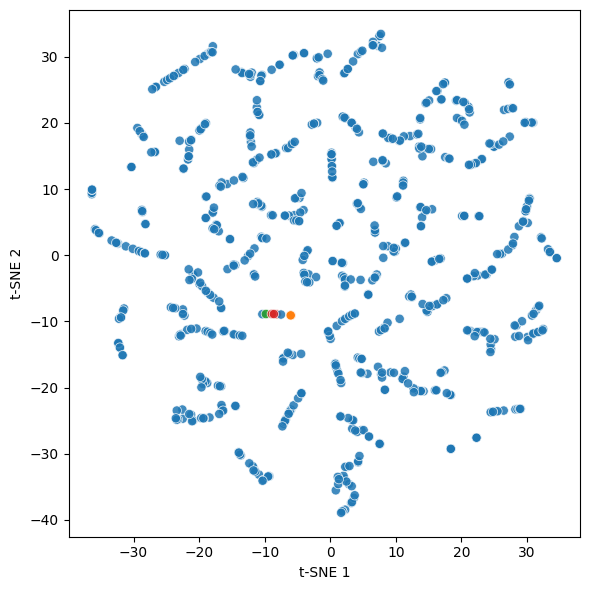

In [173]:
plot_df = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
plot_df['Cluster'] = clusters_final
plot_df['Cluster label'] = plot_df['Cluster'].apply(
    lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}'
)

n_clusters = len(set(clusters_final)) - (1 if -1 in clusters_final else 0)
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=plot_df,
    x='t-SNE 1',
    y='t-SNE 2',
    hue='Cluster label',
    s=45,
    alpha=0.85,
    palette='tab10',
    legend=False
 )

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()